CONFIGURACIÓN BASE PARA TODOS LOS LABS

In [15]:
import gc
import glob
import os
import subprocess
import time
import requests


def configure_java_64bit():
    candidates = []

    # Keep existing JAVA_HOME first if valid.
    env_java_home = os.environ.get("JAVA_HOME")
    if env_java_home:
        candidates.append(env_java_home)

    # Typical Windows JDK install locations (64-bit).
    candidates.extend(sorted(glob.glob(r"C:\\Program Files\\Eclipse Adoptium\\jdk-*"), reverse=True))
    candidates.extend(sorted(glob.glob(r"C:\\Program Files\\Microsoft\\jdk-*"), reverse=True))
    candidates.extend(sorted(glob.glob(r"C:\\Program Files\\Java\\jdk*"), reverse=True))

    selected = None
    for home in candidates:
        java_exe = os.path.join(home, "bin", "java.exe")
        if os.path.exists(java_exe):
            selected = home
            break

    if selected:
        os.environ["JAVA_HOME"] = selected
        os.environ["PATH"] = os.path.join(selected, "bin") + os.pathsep + os.environ.get("PATH", "")

    java_exe = "java"
    java_bits = "unknown"
    try:
        out = subprocess.check_output([java_exe, "-version"], stderr=subprocess.STDOUT, text=True)
        if "64-Bit" in out or "64-bit" in out:
            java_bits = "64"
        elif "Client VM" in out:
            java_bits = "32"
        print(out.strip())
    except Exception as e:
        print(f"No se pudo validar java -version: {e}")

    print(f"JAVA_HOME activo: {os.environ.get('JAVA_HOME', 'None')}")
    return java_bits


JAVA_BITS = configure_java_64bit()

from pyspark import SparkContext
from pyspark.sql import SparkSession


def reset_spark():
    # Best-effort cleanup on Spark master UI (when available).
    try:
        data = requests.get("http://localhost:8080/json", timeout=2).json()
        for app in data.get("activeapps", []):
            requests.post(
                "http://localhost:8080/app/kill/",
                data={"id": app["id"]},
                timeout=2
            )
    except Exception:
        pass

    # Hard reset for Python-side Spark handles.
    try:
        if SparkContext._active_spark_context is not None:
            SparkContext._active_spark_context.stop()
    except Exception:
        pass

    SparkSession._instantiatedSession = None
    SparkSession._activeSession = None
    SparkContext._active_spark_context = None
    gc.collect()
    time.sleep(1)

    masters = [
        "local[12]",                  # prioriza tu CPU local
        "spark://localhost:7077",     # cluster Docker desde host
        "spark://spark-master:7077"   # dentro de red Docker
    ]

    last_error = None

    # Increase capacity only when JVM is 64-bit.
    local_driver_memory = "8g" if JAVA_BITS == "64" else "2g"
    local_parallelism = "24" if JAVA_BITS == "64" else "12"
    shuffle_partitions = "48" if JAVA_BITS == "64" else "24"

    for master_url in masters:
        try:
            is_local = master_url.startswith("local")
            minio_endpoint = "http://localhost:9000" if is_local else (
                "http://localhost:9000" if "localhost" in master_url else "http://minio:9000"
            )

            builder = SparkSession.builder \
                .appName("EthicalAI") \
                .master(master_url) \
                .config("spark.sql.shuffle.partitions", shuffle_partitions) \
                .config("spark.default.parallelism", local_parallelism) \
                .config("spark.hadoop.fs.s3a.impl", "org.apache.hadoop.fs.s3a.S3AFileSystem") \
                .config("spark.hadoop.fs.s3a.endpoint", minio_endpoint) \
                .config("spark.hadoop.fs.s3a.access.key", "admin") \
                .config("spark.hadoop.fs.s3a.secret.key", "password123") \
                .config("spark.hadoop.fs.s3a.path.style.access", "true") \
                .config("spark.hadoop.fs.s3a.connection.ssl.enabled", "false")

            if is_local:
                builder = builder \
                    .config("spark.driver.bindAddress", "127.0.0.1") \
                    .config("spark.local.dir", "./.spark-tmp") \
                    .config("spark.driver.memory", local_driver_memory)
            else:
                builder = builder \
                    .config(
                        "spark.jars",
                        "/opt/extra-jars/hadoop-aws-3.3.4.jar,"
                        "/opt/extra-jars/aws-java-sdk-bundle-1.12.262.jar"
                    ) \
                    .config("spark.executor.instances", "2") \
                    .config("spark.executor.cores", "4") \
                    .config("spark.executor.memory", "4g")

            session = builder.getOrCreate()
            session.sparkContext.setLogLevel("WARN")
            _ = session.range(1).count()
            print(f"Spark inicializado con master: {master_url}")
            print(f"Perfil activo: JAVA_BITS={JAVA_BITS}, driver_memory={local_driver_memory}")
            return session
        except Exception as e:
            last_error = e
            try:
                SparkSession._instantiatedSession = None
                SparkSession._activeSession = None
                SparkContext._active_spark_context = None
            except Exception:
                pass

    raise RuntimeError(f"No se pudo inicializar Spark. Ultimo error: {last_error}")


spark = reset_spark()

openjdk version "21.0.7" 2025-04-15 LTS
OpenJDK Runtime Environment Temurin-21.0.7+6 (build 21.0.7+6-LTS)
OpenJDK 64-Bit Server VM Temurin-21.0.7+6 (build 21.0.7+6-LTS, mixed mode, sharing)
JAVA_HOME activo: C:\\Program Files\\Eclipse Adoptium\jdk-21.0.7.6-hotspot
Spark inicializado con master: local[12]
Perfil activo: JAVA_BITS=64, driver_memory=8g


CARGA DE DATOS

In [16]:
from pyspark.sql import functions as F
from pyspark.storagelevel import StorageLevel

# Recover Spark session if it was stopped.
try:
    _ = spark.range(1).count()
except Exception:
    print("Spark no disponible, reiniciando sesión...")
    spark = reset_spark()

# Force dataset with label column Risk.
sources = [
    ("local", "/workspace/data/german_credit_data-with-risk.csv"),
    ("local", "../data/german_credit_data-with-risk.csv"),
    ("local", "data/german_credit_data-with-risk.csv"),
    ("minio", "s3a://data/german_credit_data-with-risk.csv"),
]

df = None
errors = []
chosen_source = None

for source_type, source_path in sources:
    try:
        tmp = spark.read.csv(
            source_path,
            header=True,
            inferSchema=True
        )
        _ = tmp.limit(1).count()
        df = tmp
        chosen_source = (source_type, source_path)
        print(f"OK: datos cargados desde {source_type} -> {source_path}")
        break
    except Exception as e:
        errors.append(f"{source_type} -> {source_path}: {e}")

if df is None:
    raise RuntimeError(
        "No se pudo cargar german_credit_data-with-risk.csv ni desde local ni desde MinIO.\n"
        + "\n".join(errors)
    )

if "Risk" not in df.columns:
    raise RuntimeError(
        "El dataset cargado no tiene la columna 'Risk'. "
        f"Origen usado: {chosen_source}"
    )

# Performance tuning: rebalance partitions and keep dataset in memory+disk.
total_rows = df.count()
target_partitions = max(8, min(32, spark.sparkContext.defaultParallelism))
df = df.repartition(target_partitions).persist(StorageLevel.MEMORY_AND_DISK)
_ = df.count()  # materialize cache
print(f"Dataset cacheado: filas={total_rows}, particiones={df.rdd.getNumPartitions()}")

df.show(5)

OK: datos cargados desde local -> ../data/german_credit_data-with-risk.csv
Dataset cacheado: filas=1000, particiones=24
+---+---+----+---+-------+---------------+----------------+-------------+--------+--------+----+
|_c0|Age| Sex|Job|Housing|Saving accounts|Checking account|Credit amount|Duration| Purpose|Risk|
+---+---+----+---+-------+---------------+----------------+-------------+--------+--------+----+
|855| 33|male|  2|    own|       moderate|              NA|         1474|      24|     car|good|
|330| 75|male|  3|   free|         little|          little|         6615|      24|     car|good|
|304| 44|male|  2|   free|     quite rich|              NA|        10127|      48|     car| bad|
|270| 32|male|  2|    own|             NA|              NA|         2662|      18|     car|good|
|358| 28|male|  2|    own|         little|              NA|          776|      12|radio/TV|good|
+---+---+----+---+-------+---------------+----------------+-------------+--------+--------+----+
only sh

PREPROCESAMIENTO BASE

In [17]:
from pyspark.sql import functions as F
from pyspark.ml.feature import StringIndexer
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml import Pipeline

# LogisticRegression requires numeric label: bad->1.0, good->0.0
df_model = df.withColumn(
    "RiskLabel",
    F.when(F.lower(F.col("Risk")) == F.lit("bad"), F.lit(1.0)).otherwise(F.lit(0.0))
)

categorical_cols = [
    "Sex",
    "Housing",
    "Saving accounts",
    "Checking account",
    "Purpose"
]

indexers = [
    StringIndexer(
        inputCol=col,
        outputCol=f"{col}Index",
        handleInvalid="keep"
    )
    for col in categorical_cols
]

feature_columns = [
    "Age",
    "Credit amount",
    "Duration"
] + [f"{c}Index" for c in categorical_cols]

assembler = VectorAssembler(
    inputCols=feature_columns,
    outputCol="features",
    handleInvalid="skip"
)

lr = LogisticRegression(
    featuresCol="features",
    labelCol="RiskLabel",
    maxIter=80
)

pipeline = Pipeline(
    stages=indexers + [assembler, lr]
)

train, test = df_model.randomSplit([0.8, 0.2], seed=42)

# Cache train/test because they are reused during fit/transform.
train = train.cache()
test = test.cache()
_ = train.count()
_ = test.count()

model = pipeline.fit(train)
predictions = model.transform(test)

# Release cached splits to keep memory healthy for next labs.
train.unpersist()
test.unpersist()

DataFrame[_c0: int, Age: int, Sex: string, Job: int, Housing: string, Saving accounts: string, Checking account: string, Credit amount: int, Duration: int, Purpose: string, Risk: string, RiskLabel: double]

MODELOS ADICIONALES Y EVALUACIÓN COMPARATIVA

In [23]:
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, MultilayerPerceptronClassifier
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import (
    BinaryClassificationEvaluator,
    RegressionEvaluator,
    MulticlassClassificationEvaluator,
 )

# Build reusable numeric feature matrix once for all Spark models.
prep_pipeline = Pipeline(stages=indexers + [assembler])
prep_model = prep_pipeline.fit(df_model)
prepared = prep_model.transform(df_model).select("features", "RiskLabel")

train_p, test_p = prepared.randomSplit([0.8, 0.2], seed=42)
train_p = train_p.cache()
test_p = test_p.cache()
_ = train_p.count()
_ = test_p.count()

auc_eval = BinaryClassificationEvaluator(labelCol="RiskLabel", metricName="areaUnderROC")
pr_eval = BinaryClassificationEvaluator(labelCol="RiskLabel", metricName="areaUnderPR")
r2_eval = RegressionEvaluator(labelCol="RiskLabel", predictionCol="prediction", metricName="r2")

precision_eval = MulticlassClassificationEvaluator(
    labelCol="RiskLabel",
    predictionCol="prediction",
    metricName="weightedPrecision",
)
recall_eval = MulticlassClassificationEvaluator(
    labelCol="RiskLabel",
    predictionCol="prediction",
    metricName="weightedRecall",
)
f1_eval = MulticlassClassificationEvaluator(
    labelCol="RiskLabel",
    predictionCol="prediction",
    metricName="f1",
)

results = []

def eval_binary_model(name, model, raw_col="rawPrediction"):
    pred_train = model.transform(train_p)
    pred_test = model.transform(test_p)

    auc_train = auc_eval.setRawPredictionCol(raw_col).evaluate(pred_train)
    auc_test = auc_eval.setRawPredictionCol(raw_col).evaluate(pred_test)
    pr_train = pr_eval.setRawPredictionCol(raw_col).evaluate(pred_train)
    pr_test = pr_eval.setRawPredictionCol(raw_col).evaluate(pred_test)

    r2_train = r2_eval.evaluate(pred_train)
    r2_test = r2_eval.evaluate(pred_test)

    precision_train = precision_eval.evaluate(pred_train)
    precision_test = precision_eval.evaluate(pred_test)
    recall_train = recall_eval.evaluate(pred_train)
    recall_test = recall_eval.evaluate(pred_test)
    f1_train = f1_eval.evaluate(pred_train)
    f1_test = f1_eval.evaluate(pred_test)

    results.append({
        "model": name,
        "AUC_train": float(auc_train),
        "AUC_test": float(auc_test),
        "PR_AUC_train": float(pr_train),
        "PR_AUC_test": float(pr_test),
        "R2_train": float(r2_train),
        "R2_test": float(r2_test),
        "Precision_train": float(precision_train),
        "Precision_test": float(precision_test),
        "Recall_train": float(recall_train),
        "Recall_test": float(recall_test),
        "F1_train": float(f1_train),
        "F1_test": float(f1_test),
    })

# 1) Logistic Regression
lr2 = LogisticRegression(featuresCol="features", labelCol="RiskLabel", maxIter=80)
lr2_model = lr2.fit(train_p)
eval_binary_model("LogisticRegression", lr2_model, raw_col="rawPrediction")

# 2) Random Forest
rf = RandomForestClassifier(
    featuresCol="features",
    labelCol="RiskLabel",
    numTrees=200,
    maxDepth=8,
    seed=42
)
rf_model = rf.fit(train_p)
eval_binary_model("RandomForest", rf_model, raw_col="rawPrediction")

# 3) Neural Network (MLP)
input_size = len(feature_columns)
mlp = MultilayerPerceptronClassifier(
    featuresCol="features",
    labelCol="RiskLabel",
    layers=[input_size, 16, 8, 2],
    blockSize=64,
    maxIter=120,
    seed=42
)
mlp_model = mlp.fit(train_p)
eval_binary_model("NeuralNetwork_MLP", mlp_model, raw_col="rawPrediction")

# 4) Linear Regression (score baseline + threshold 0.5 for classification metrics)
linreg = LinearRegression(featuresCol="features", labelCol="RiskLabel", maxIter=80)
linreg_model = linreg.fit(train_p)
pred_train_lr = linreg_model.transform(train_p)
pred_test_lr = linreg_model.transform(test_p)

pred_train_lr_cls = pred_train_lr.withColumn(
    "prediction",
    F.when(F.col("prediction") >= F.lit(0.5), F.lit(1.0)).otherwise(F.lit(0.0)),
)
pred_test_lr_cls = pred_test_lr.withColumn(
    "prediction",
    F.when(F.col("prediction") >= F.lit(0.5), F.lit(1.0)).otherwise(F.lit(0.0)),
)

results.append({
    "model": "LinearRegression",
    "AUC_train": float(auc_eval.setRawPredictionCol("prediction").evaluate(pred_train_lr)),
    "AUC_test": float(auc_eval.setRawPredictionCol("prediction").evaluate(pred_test_lr)),
    "PR_AUC_train": float(pr_eval.setRawPredictionCol("prediction").evaluate(pred_train_lr)),
    "PR_AUC_test": float(pr_eval.setRawPredictionCol("prediction").evaluate(pred_test_lr)),
    "R2_train": float(r2_eval.evaluate(pred_train_lr)),
    "R2_test": float(r2_eval.evaluate(pred_test_lr)),
    "Precision_train": float(precision_eval.evaluate(pred_train_lr_cls)),
    "Precision_test": float(precision_eval.evaluate(pred_test_lr_cls)),
    "Recall_train": float(recall_eval.evaluate(pred_train_lr_cls)),
    "Recall_test": float(recall_eval.evaluate(pred_test_lr_cls)),
    "F1_train": float(f1_eval.evaluate(pred_train_lr_cls)),
    "F1_test": float(f1_eval.evaluate(pred_test_lr_cls)),
})

# 5) Isolation Forest (unsupervised, sklearn)
try:
    from sklearn.ensemble import IsolationForest
    from sklearn.metrics import (
        roc_auc_score,
        average_precision_score,
        r2_score,
        precision_score,
        recall_score,
        f1_score,
    )
    import numpy as np

    train_rows = train_p.select("features", "RiskLabel").coalesce(1).collect()
    test_rows = test_p.select("features", "RiskLabel").coalesce(1).collect()

    X_train = np.array([r["features"].toArray() for r in train_rows])
    y_train = np.array([int(r["RiskLabel"]) for r in train_rows])
    X_test = np.array([r["features"].toArray() for r in test_rows])
    y_test = np.array([int(r["RiskLabel"]) for r in test_rows])

    iso = IsolationForest(
        n_estimators=300,
        contamination=0.3,
        random_state=42,
        n_jobs=-1
)
    iso.fit(X_train)

    # Higher score means more anomalous risk candidate.
    train_score = -iso.score_samples(X_train)
    test_score = -iso.score_samples(X_test)

    # Convert anomaly score to binary prediction using train contamination quantile.
    threshold = float(np.quantile(train_score, 0.7))
    yhat_train = (train_score >= threshold).astype(int)
    yhat_test = (test_score >= threshold).astype(int)

    results.append({
        "model": "IsolationForest",
        "AUC_train": float(roc_auc_score(y_train, train_score)),
        "AUC_test": float(roc_auc_score(y_test, test_score)),
        "PR_AUC_train": float(average_precision_score(y_train, train_score)),
        "PR_AUC_test": float(average_precision_score(y_test, test_score)),
        "R2_train": float(r2_score(y_train, train_score)),
        "R2_test": float(r2_score(y_test, test_score)),
        "Precision_train": float(precision_score(y_train, yhat_train, zero_division=0)),
        "Precision_test": float(precision_score(y_test, yhat_test, zero_division=0)),
        "Recall_train": float(recall_score(y_train, yhat_train, zero_division=0)),
        "Recall_test": float(recall_score(y_test, yhat_test, zero_division=0)),
        "F1_train": float(f1_score(y_train, yhat_train, zero_division=0)),
        "F1_test": float(f1_score(y_test, yhat_test, zero_division=0)),
    })
except ImportError:
    print("IsolationForest omitido: falta scikit-learn.")
except Exception as e:
    print(f"IsolationForest omitido por error de ejecución: {e}")

# Clean cache from benchmarking.
train_p.unpersist()
test_p.unpersist()

import pandas as pd
results_pd = pd.DataFrame(results).sort_values("AUC_test", ascending=False)
display(results_pd)

,model,AUC_train,AUC_test,PR_AUC_train,PR_AUC_test,R2_train,R2_test,Precision_train,Precision_test,Recall_train,Recall_test,F1_train,F1_test
1,RandomForest,0.977613,0.726953,0.958322,0.466458,0.584162,-0.394558,0.915997,0.698197,0.911950,0.717073,0.908470,0.704087
0,LogisticRegression,0.735485,0.638400,0.546312,0.361069,-0.295040,-0.707131,0.703051,0.607743,0.725786,0.653659,0.693200,0.623396
3,LinearRegression,0.734521,0.636289,0.544479,0.359506,0.143776,0.001243,0.699804,0.614699,0.723270,0.668293,0.683434,0.629943
4,IsolationForest,0.576831,0.517007,0.386319,0.336555,-0.135275,-0.217927,0.351464,0.246575,0.347107,0.310345,0.349272,0.274809
2,NeuralNetwork_MLP,0.491422,0.493197,0.213605,0.141463,-0.437613,-0.394558,0.483856,0.514194,0.695597,0.717073,0.570720,0.598919


EVOLUCIÓN DE ENTRENAMIENTO Y MATRIZ DE CONFUSIÓN

,AUC_test,PR_AUC_test,Precision_test,Recall_test,F1_test,model,step,step_name
24,0.491907,0.308240,0.275362,0.327586,0.299213,IsolationForest,25,n_estimators
25,0.500235,0.313780,0.259740,0.344828,0.296296,IsolationForest,50,n_estimators
26,0.506920,0.318252,0.277778,0.344828,0.307692,IsolationForest,100,n_estimators
27,0.510556,0.330199,0.260274,0.327586,0.290076,IsolationForest,200,n_estimators
28,0.517007,0.336555,0.246575,0.310345,0.274809,IsolationForest,300,n_estimators
17,0.636289,0.359506,0.614699,0.668293,0.629943,LinearRegression,1,maxIter
18,0.636289,0.359506,0.614699,0.668293,0.629943,LinearRegression,2,maxIter
19,0.636289,0.359506,0.614699,0.668293,0.629943,LinearRegression,5,maxIter
20,0.636289,0.359506,0.614699,0.668293,0.629943,LinearRegression,10,maxIter
21,0.636289,0.359506,0.614699,0.668293,0.629943,LinearRegression,20,maxIter


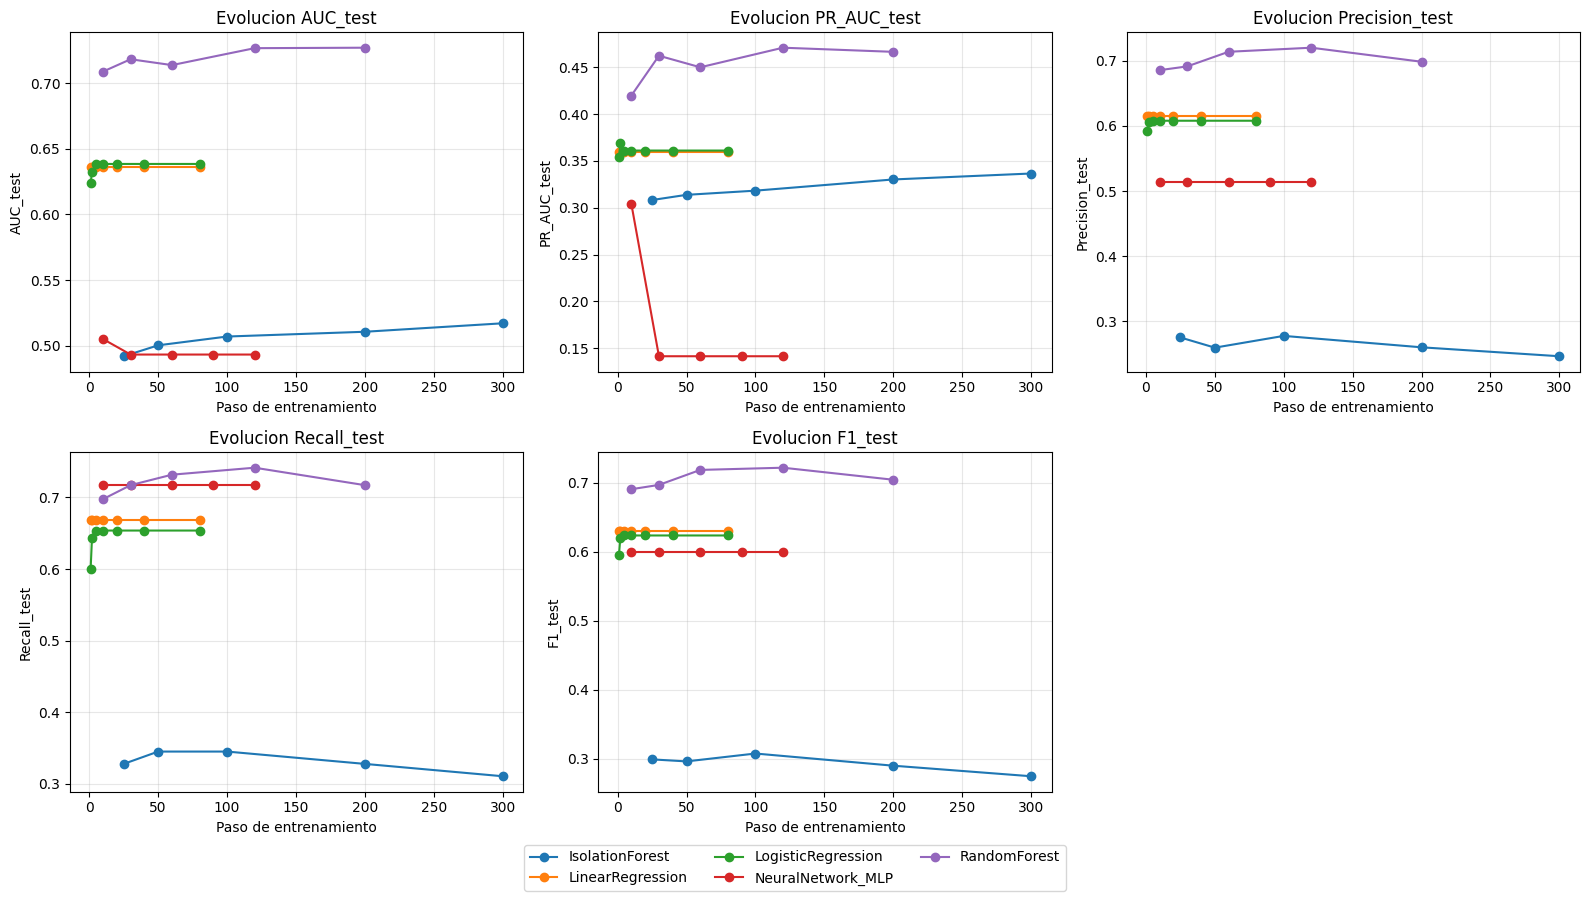

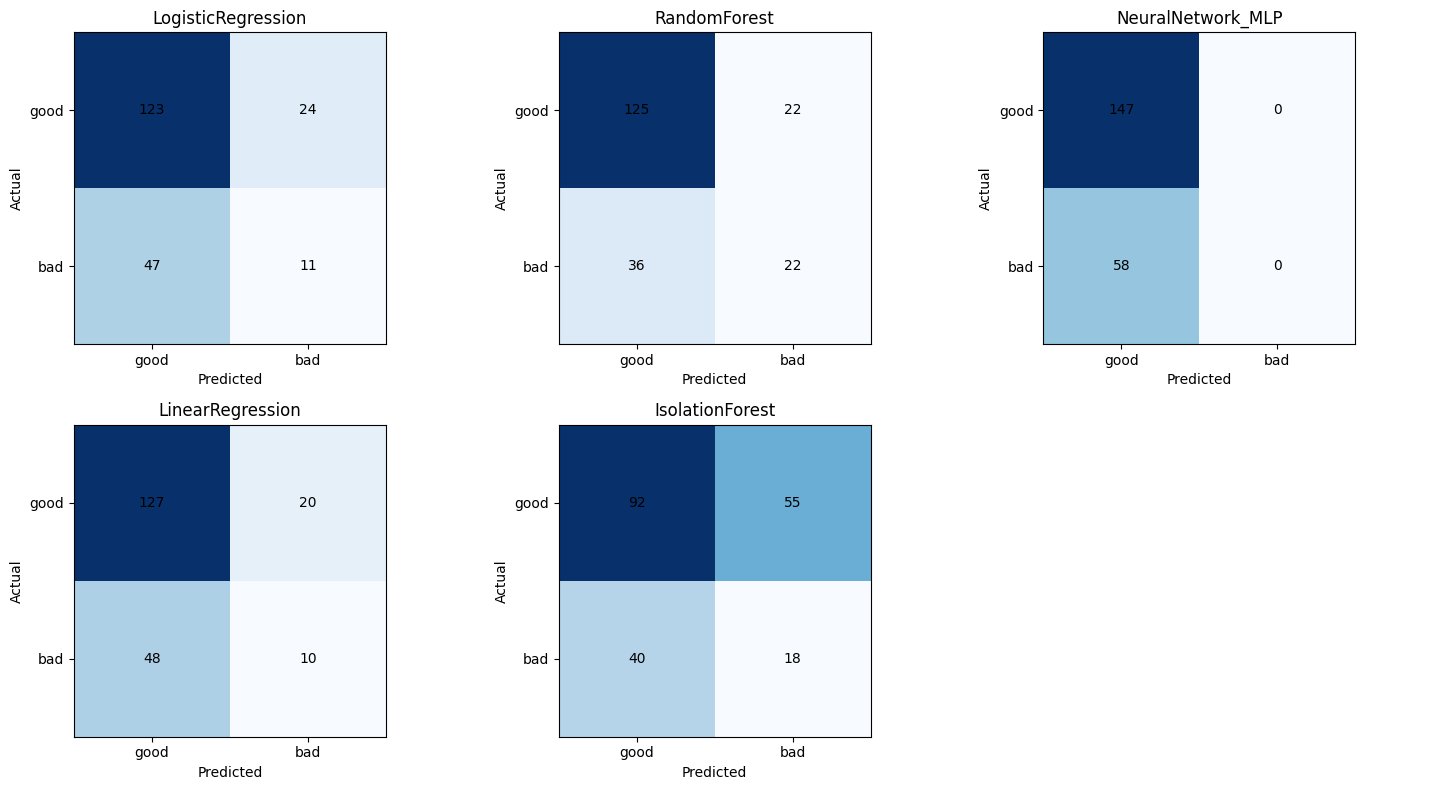

In [27]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import functions as F
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, MultilayerPerceptronClassifier
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

# Evaluators
auc_eval = BinaryClassificationEvaluator(labelCol="RiskLabel", metricName="areaUnderROC")
pr_eval = BinaryClassificationEvaluator(labelCol="RiskLabel", metricName="areaUnderPR")
precision_eval = MulticlassClassificationEvaluator(
    labelCol="RiskLabel", predictionCol="prediction", metricName="weightedPrecision"
 )
recall_eval = MulticlassClassificationEvaluator(
    labelCol="RiskLabel", predictionCol="prediction", metricName="weightedRecall"
 )
f1_eval = MulticlassClassificationEvaluator(
    labelCol="RiskLabel", predictionCol="prediction", metricName="f1"
 )

def evaluate_prediction_df(pred_df, raw_col="rawPrediction"):
    return {
        "AUC_test": float(auc_eval.setRawPredictionCol(raw_col).evaluate(pred_df)),
        "PR_AUC_test": float(pr_eval.setRawPredictionCol(raw_col).evaluate(pred_df)),
        "Precision_test": float(precision_eval.evaluate(pred_df)),
        "Recall_test": float(recall_eval.evaluate(pred_df)),
        "F1_test": float(f1_eval.evaluate(pred_df)),
    }

# ---------- 1) METRIC EVOLUTION CURVES BY MODEL ----------
progress_rows = []

# Logistic Regression evolution by maxIter
for it in [1, 2, 5, 10, 20, 40, 80]:
    m = LogisticRegression(featuresCol="features", labelCol="RiskLabel", maxIter=it).fit(train_p)
    pred = m.transform(test_p)
    metrics = evaluate_prediction_df(pred, raw_col="rawPrediction")
    metrics.update({"model": "LogisticRegression", "step": it, "step_name": "maxIter"})
    progress_rows.append(metrics)

# Random Forest evolution by numTrees
for nt in [10, 30, 60, 120, 200]:
    m = RandomForestClassifier(
        featuresCol="features", labelCol="RiskLabel", numTrees=nt, maxDepth=8, seed=42
    ).fit(train_p)
    pred = m.transform(test_p)
    metrics = evaluate_prediction_df(pred, raw_col="rawPrediction")
    metrics.update({"model": "RandomForest", "step": nt, "step_name": "numTrees"})
    progress_rows.append(metrics)

# Neural Network evolution by maxIter
input_size = len(feature_columns)
for it in [10, 30, 60, 90, 120]:
    m = MultilayerPerceptronClassifier(
        featuresCol="features",
        labelCol="RiskLabel",
        layers=[input_size, 16, 8, 2],
        blockSize=64,
        maxIter=it,
        seed=42,
    ).fit(train_p)
    pred = m.transform(test_p)
    metrics = evaluate_prediction_df(pred, raw_col="rawPrediction")
    metrics.update({"model": "NeuralNetwork_MLP", "step": it, "step_name": "maxIter"})
    progress_rows.append(metrics)

# Linear Regression evolution by maxIter (threshold at 0.5 for class metrics)
for it in [1, 2, 5, 10, 20, 40, 80]:
    m = LinearRegression(featuresCol="features", labelCol="RiskLabel", maxIter=it).fit(train_p)
    pred_raw = m.transform(test_p)
    pred_cls = pred_raw.withColumn(
        "prediction",
        F.when(F.col("prediction") >= F.lit(0.5), F.lit(1.0)).otherwise(F.lit(0.0)),
    )
    metrics = {
        "AUC_test": float(auc_eval.setRawPredictionCol("prediction").evaluate(pred_raw)),
        "PR_AUC_test": float(pr_eval.setRawPredictionCol("prediction").evaluate(pred_raw)),
        "Precision_test": float(precision_eval.evaluate(pred_cls)),
        "Recall_test": float(recall_eval.evaluate(pred_cls)),
        "F1_test": float(f1_eval.evaluate(pred_cls)),
    }
    metrics.update({"model": "LinearRegression", "step": it, "step_name": "maxIter"})
    progress_rows.append(metrics)

# Isolation Forest evolution by n_estimators (if sklearn + arrays available)
if "y_train" in globals() and "y_test" in globals() and "X_train" in globals() and "X_test" in globals():
    try:
        from sklearn.ensemble import IsolationForest
        from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, f1_score

        for nt in [25, 50, 100, 200, 300]:
            iso = IsolationForest(
                n_estimators=nt, contamination=0.3, random_state=42, n_jobs=-1
            )
            iso.fit(X_train)
            train_score = -iso.score_samples(X_train)
            test_score = -iso.score_samples(X_test)
            threshold = float(np.quantile(train_score, 0.7))
            yhat_test = (test_score >= threshold).astype(int)

            progress_rows.append({
                "model": "IsolationForest",
                "step": nt,
                "step_name": "n_estimators",
                "AUC_test": float(roc_auc_score(y_test, test_score)),
                "PR_AUC_test": float(average_precision_score(y_test, test_score)),
                "Precision_test": float(precision_score(y_test, yhat_test, zero_division=0)),
                "Recall_test": float(recall_score(y_test, yhat_test, zero_division=0)),
                "F1_test": float(f1_score(y_test, yhat_test, zero_division=0)),
            })
    except Exception as e:
        print(f"IsolationForest evolucion omitida: {e}")

progress_df = pd.DataFrame(progress_rows)
display(progress_df.sort_values(["model", "step"]))

# Plot metrics evolution
metrics_to_plot = ["AUC_test", "PR_AUC_test", "Precision_test", "Recall_test", "F1_test"]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for idx, metric in enumerate(metrics_to_plot):
    ax = axes[idx]
    for model_name, grp in progress_df.groupby("model"):
        grp = grp.sort_values("step")
        ax.plot(grp["step"], grp[metric], marker="o", label=model_name)
    ax.set_title(f"Evolucion {metric}")
    ax.set_xlabel("Paso de entrenamiento")
    ax.set_ylabel(metric)
    ax.grid(alpha=0.3)

axes[5].axis("off")
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=3)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

# ---------- 2) CONFUSION MATRIX AS HEATMAP ----------
def confusion_matrix_from_spark(pred_df):
    rows = (
        pred_df
        .select(
            F.col("RiskLabel").cast("int").alias("label"),
            F.col("prediction").cast("int").alias("pred"),
        )
        .groupBy("label", "pred")
        .count()
        .collect()
    )
    cm = np.zeros((2, 2), dtype=int)
    for r in rows:
        cm[int(r["label"]), int(r["pred"])] = int(r["count"])
    return cm

# Use best current trained models from previous cell.
pred_lr_test = lr2_model.transform(test_p)
pred_rf_test = rf_model.transform(test_p)
pred_mlp_test = mlp_model.transform(test_p)
pred_lin_test = linreg_model.transform(test_p).withColumn(
    "prediction",
    F.when(F.col("prediction") >= F.lit(0.5), F.lit(1.0)).otherwise(F.lit(0.0)),
)

cm_items = [
    ("LogisticRegression", confusion_matrix_from_spark(pred_lr_test)),
    ("RandomForest", confusion_matrix_from_spark(pred_rf_test)),
    ("NeuralNetwork_MLP", confusion_matrix_from_spark(pred_mlp_test)),
    ("LinearRegression", confusion_matrix_from_spark(pred_lin_test)),
]

if "y_test" in globals() and "yhat_test" in globals():
    try:
        from sklearn.metrics import confusion_matrix
        cm_iso = confusion_matrix(y_test, yhat_test, labels=[0, 1])
        cm_items.append(("IsolationForest", cm_iso))
    except Exception as e:
        print(f"Matriz de confusion IsolationForest omitida: {e}")

class_labels = ["good", "bad"]
n = len(cm_items)
rows = 2
cols = 3
fig, axes = plt.subplots(rows, cols, figsize=(15, 8))
axes = axes.flatten()

for i, (name, cm) in enumerate(cm_items):
    ax = axes[i]
    ax.imshow(cm, cmap="Blues")
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    ax.set_xticks([0, 1])
    ax.set_yticks([0, 1])
    ax.set_xticklabels(class_labels)
    ax.set_yticklabels(class_labels)
    for r in range(2):
        for c in range(2):
            ax.text(c, r, str(cm[r, c]), ha="center", va="center", color="black")

for j in range(n, rows * cols):
    axes[j].axis("off")

plt.tight_layout()
plt.show()

MONITOREO CON WANDB (wandb.ai)

In [29]:
import os
import sys
import subprocess
from pathlib import Path

# Install dependencies if missing.
try:
    import wandb
except Exception:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "wandb", "python-dotenv", "-q"])
    import wandb

from dotenv import load_dotenv

# Try multiple .env locations (notebook dir and workspace root).
candidate_envs = [
    Path.cwd() / ".env",
    Path.cwd().parent / ".env",
    Path.cwd().parent.parent / ".env",
]

for env_path in candidate_envs:
    if env_path.exists():
        load_dotenv(env_path, override=True)

api_key = os.getenv("API_KEY_wandb_IA")

if not api_key:
    raise RuntimeError("No se encontro API_KEY_wandb_IA en .env")

# Login without printing the secret.
wandb.login(key=api_key, relogin=True)

run = wandb.init(
    project="ethical-ai-lab1",
    name="lab1_fairness_monitoring",
    config={
        "dataset": "german_credit_data-with-risk.csv",
        "label": "RiskLabel",
        "models": [
            "LogisticRegression",
            "RandomForest",
            "NeuralNetwork_MLP",
            "LinearRegression",
            "IsolationForest",
        ],
    },
)

# Log metrics table from benchmark cell.
if "results_pd" in globals() and not results_pd.empty:
    results_to_log = results_pd.copy()
    results_to_log = results_to_log.reset_index(drop=True)
    wandb.log({"model_metrics_table": wandb.Table(dataframe=results_to_log)})

    # Also push top model summary metrics for quick dashboard view.
    best = results_to_log.iloc[0].to_dict()
    summary_metrics = {}
    for k, v in best.items():
        if isinstance(v, (int, float)):
            summary_metrics[f"best_{k}"] = float(v)
    if summary_metrics:
        wandb.log(summary_metrics)

    print("W&B conectado y metricas enviadas correctamente.")
    print(f"Run URL: {run.url}")
else:
    print("W&B conectado, pero no se encontro results_pd para registrar.")

run.finish()

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: C:\Users\JD\_netrc
wandb: Currently logged in as: campi010499 (campi010499-intep) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B conectado y metricas enviadas correctamente.
Run URL: https://wandb.ai/campi010499-intep/ethical-ai-lab1/runs/7puoeuw7


best_AUC_test,▁
best_AUC_train,▁
best_F1_test,▁
best_F1_train,▁
best_PR_AUC_test,▁
best_PR_AUC_train,▁
best_Precision_test,▁
best_Precision_train,▁
best_R2_test,▁
best_R2_train,▁
+2,...


VALIDACIÓN DE ESTABILIDAD CON 10 SEMILLAS

In [31]:
import numpy as np
import pandas as pd
from pyspark.sql import functions as F
from pyspark.ml import Pipeline
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, MultilayerPerceptronClassifier
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator, MulticlassClassificationEvaluator

seeds = list(range(1, 11))

auc_eval = BinaryClassificationEvaluator(labelCol="RiskLabel", metricName="areaUnderROC")
pr_eval = BinaryClassificationEvaluator(labelCol="RiskLabel", metricName="areaUnderPR")
precision_eval = MulticlassClassificationEvaluator(
    labelCol="RiskLabel", predictionCol="prediction", metricName="weightedPrecision"
 )
recall_eval = MulticlassClassificationEvaluator(
    labelCol="RiskLabel", predictionCol="prediction", metricName="weightedRecall"
 )
f1_eval = MulticlassClassificationEvaluator(
    labelCol="RiskLabel", predictionCol="prediction", metricName="f1"
 )

def binary_metrics(pred_df, raw_col="rawPrediction"):
    return {
        "AUC": float(auc_eval.setRawPredictionCol(raw_col).evaluate(pred_df)),
        "PR_AUC": float(pr_eval.setRawPredictionCol(raw_col).evaluate(pred_df)),
        "Precision": float(precision_eval.evaluate(pred_df)),
        "Recall": float(recall_eval.evaluate(pred_df)),
        "F1": float(f1_eval.evaluate(pred_df)),
    }

records = []

prep_pipeline_seed = Pipeline(stages=indexers + [assembler])
prep_model_seed = prep_pipeline_seed.fit(df_model)
prepared_base = prep_model_seed.transform(df_model).select("features", "RiskLabel")

for seed in seeds:
    train_s, test_s = prepared_base.randomSplit([0.8, 0.2], seed=seed)
    train_s = train_s.cache()
    test_s = test_s.cache()
    _ = train_s.count()
    _ = test_s.count()

    # Logistic Regression
    lr_s = LogisticRegression(featuresCol="features", labelCol="RiskLabel", maxIter=80).fit(train_s)
    pred_lr = lr_s.transform(test_s)
    m_lr = binary_metrics(pred_lr, raw_col="rawPrediction")
    records.append({"seed": seed, "model": "LogisticRegression", **m_lr})

    # Random Forest
    rf_s = RandomForestClassifier(
        featuresCol="features", labelCol="RiskLabel", numTrees=200, maxDepth=8, seed=seed
    ).fit(train_s)
    pred_rf = rf_s.transform(test_s)
    m_rf = binary_metrics(pred_rf, raw_col="rawPrediction")
    records.append({"seed": seed, "model": "RandomForest", **m_rf})

    # Neural Network (MLP)
    input_size = len(feature_columns)
    mlp_s = MultilayerPerceptronClassifier(
        featuresCol="features",
        labelCol="RiskLabel",
        layers=[input_size, 16, 8, 2],
        blockSize=64,
        maxIter=120,
        seed=seed,
    ).fit(train_s)
    pred_mlp = mlp_s.transform(test_s)
    m_mlp = binary_metrics(pred_mlp, raw_col="rawPrediction")
    records.append({"seed": seed, "model": "NeuralNetwork_MLP", **m_mlp})

    # Linear Regression (threshold 0.5 for classification metrics)
    lin_s = LinearRegression(featuresCol="features", labelCol="RiskLabel", maxIter=80).fit(train_s)
    pred_lin_raw = lin_s.transform(test_s)
    pred_lin_cls = pred_lin_raw.withColumn(
        "prediction",
        F.when(F.col("prediction") >= F.lit(0.5), F.lit(1.0)).otherwise(F.lit(0.0)),
    )
    m_lin = {
        "AUC": float(auc_eval.setRawPredictionCol("prediction").evaluate(pred_lin_raw)),
        "PR_AUC": float(pr_eval.setRawPredictionCol("prediction").evaluate(pred_lin_raw)),
        "Precision": float(precision_eval.evaluate(pred_lin_cls)),
        "Recall": float(recall_eval.evaluate(pred_lin_cls)),
        "F1": float(f1_eval.evaluate(pred_lin_cls)),
    }
    records.append({"seed": seed, "model": "LinearRegression", **m_lin})

    # Isolation Forest (optional sklearn path)
    try:
        from sklearn.ensemble import IsolationForest
        from sklearn.metrics import roc_auc_score, average_precision_score, precision_score, recall_score, f1_score

        train_rows = train_s.select("features", "RiskLabel").coalesce(1).collect()
        test_rows = test_s.select("features", "RiskLabel").coalesce(1).collect()

        X_train = np.array([r["features"].toArray() for r in train_rows])
        y_train = np.array([int(r["RiskLabel"]) for r in train_rows])
        X_test = np.array([r["features"].toArray() for r in test_rows])
        y_test = np.array([int(r["RiskLabel"]) for r in test_rows])

        iso = IsolationForest(
            n_estimators=300, contamination=0.3, random_state=seed, n_jobs=-1
        )
        iso.fit(X_train)
        train_score = -iso.score_samples(X_train)
        test_score = -iso.score_samples(X_test)
        thr = float(np.quantile(train_score, 0.7))
        yhat = (test_score >= thr).astype(int)

        records.append({
            "seed": seed,
            "model": "IsolationForest",
            "AUC": float(roc_auc_score(y_test, test_score)),
            "PR_AUC": float(average_precision_score(y_test, test_score)),
            "Precision": float(precision_score(y_test, yhat, zero_division=0)),
            "Recall": float(recall_score(y_test, yhat, zero_division=0)),
            "F1": float(f1_score(y_test, yhat, zero_division=0)),
        })
    except Exception as e:
        print(f"Seed {seed} - IsolationForest omitido: {e}")

    train_s.unpersist()
    test_s.unpersist()

seed_results_pd = pd.DataFrame(records).sort_values(["model", "seed"]).reset_index(drop=True)
stability_summary_pd = (
    seed_results_pd.groupby("model")[["AUC", "PR_AUC", "Precision", "Recall", "F1"]]
    .agg(["mean", "std", "min", "max"])
    .round(4)
)

print("Resultados por semilla (10 seeds):")
display(seed_results_pd)
print("Resumen de estabilidad por modelo:")
display(stability_summary_pd)

# Optional: upload to W&B as a dedicated run
try:
    import wandb
    run_seed = wandb.init(
        project="ethical-ai-lab1",
        name="lab1_fairness_10seeds_stability",
        config={"seeds": seeds, "purpose": "stability-validation"},
        reinit=True,
    )
    wandb.log({
        "seed_results_table": wandb.Table(dataframe=seed_results_pd),
        "stability_summary_table": wandb.Table(dataframe=stability_summary_pd.reset_index()),
    })
    print(f"W&B run 10 seeds: {run_seed.url}")
    run_seed.finish()
except Exception as e:
    print(f"No se pudo subir a W&B en esta celda: {e}")

Resultados por semilla (10 seeds):


,seed,model,AUC,PR_AUC,Precision,Recall,F1
0,1,IsolationForest,0.564599,0.384038,0.360656,0.343750,0.352000
1,2,IsolationForest,0.557278,0.344511,0.313433,0.396226,0.350000
2,3,IsolationForest,0.520811,0.340777,0.290323,0.321429,0.305085
3,4,IsolationForest,0.521383,0.347394,0.269841,0.326923,0.295652
4,5,IsolationForest,0.547037,0.321756,0.298246,0.298246,0.298246
5,6,IsolationForest,0.478001,0.308379,0.264706,0.333333,0.295082
6,7,IsolationForest,0.588313,0.378707,0.294118,0.306122,0.300000
7,8,IsolationForest,0.568868,0.380805,0.377049,0.365079,0.370968
8,9,IsolationForest,0.589682,0.467466,0.406250,0.382353,0.393939
9,10,IsolationForest,0.573743,0.325795,0.308824,0.411765,0.352941


Resumen de estabilidad por modelo:


AUC                  ...      F1                
                      mean     std     min  ...     std     min     max
model                                       ...                        
IsolationForest     0.5510  0.0351  0.4780  ...  0.0366  0.2951  0.3939
LinearRegression    0.6934  0.0186  0.6660  ...  0.0481  0.5274  0.6976
LogisticRegression  0.6933  0.0208  0.6613  ...  0.0405  0.5703  0.7247
NeuralNetwork_MLP   0.5362  0.0553  0.4732  ...  0.0412  0.5022  0.6286
RandomForest        0.7526  0.0293  0.6947  ...  0.0435  0.6207  0.7701

[5 rows x 20 columns]

wandb: WARNING Using a boolean value for 'reinit' is deprecated. Use 'return_previous' or 'finish_previous' instead.


No se pudo subir a W&B en esta celda: columns argument expects list of strings or ints


In [33]:
import wandb
import pandas as pd

if "seed_results_pd" not in globals() or seed_results_pd.empty:
    raise RuntimeError("No existen resultados de 10 semillas. Ejecuta primero la celda de validacion.")

models_in_results = seed_results_pd["model"].unique().tolist()
metric_cols = ["AUC", "PR_AUC", "Precision", "Recall", "F1"]

# ---- 1) Run global: todas las semillas en una sola grafica ----
run_global = wandb.init(
    project="ethical-ai-lab1",
    name="seeds_all_models_overview",
    config={"seeds": list(range(1, 11)), "models": models_in_results},
    reinit=True,
)

# Log cada fila (seed x model) como un paso usando seed como step.
# W&B agrupa por el nombre de la metrica y grafica todas las series juntas.
for _, row in seed_results_pd.iterrows():
    log_dict = {f"{row['model']}/{m}": row[m] for m in metric_cols}
    log_dict["seed"] = int(row["seed"])
    wandb.log(log_dict, step=int(row["seed"]))

# Log tabla completa para la vista de tabla en W&B.
wandb.log({"all_seeds_table": wandb.Table(dataframe=seed_results_pd)})

print(f"Run global (todas las semillas): {run_global.url}")
run_global.finish()

# ---- 2) Una run por modelo: cada seed es un paso -> grafica por modelo ----
best_per_model = []

for model_name in models_in_results:
    grp = seed_results_pd[seed_results_pd["model"] == model_name].sort_values("seed")

    run_m = wandb.init(
        project="ethical-ai-lab1",
        name=f"seeds_{model_name}",
        config={"model": model_name, "seeds": grp["seed"].tolist()},
        reinit=True,
    )

    # Log cada seed como un paso: W&B genera curvas automaticas por metrica.
    for _, row in grp.iterrows():
        log_dict = {m: row[m] for m in metric_cols}
        log_dict["seed"] = int(row["seed"])
        wandb.log(log_dict, step=int(row["seed"]))

    # Mejor seed por AUC.
    best_row = grp.loc[grp["AUC"].idxmax()]
    best_seed = int(best_row["seed"])
    wandb.summary["best_seed_by_AUC"] = best_seed
    wandb.summary["best_AUC"] = float(best_row["AUC"])
    wandb.summary["best_F1"] = float(best_row["F1"])

    best_per_model.append({
        "model": model_name,
        "best_seed": best_seed,
        **{f"best_{m}": float(best_row[m]) for m in metric_cols},
    })

    print(f"{model_name}: mejor seed = {best_seed} | AUC={best_row['AUC']:.4f} | F1={best_row['F1']:.4f} | Run: {run_m.url}")
    run_m.finish()

print("")
print("=== RESUMEN: MEJOR SEMILLA POR MODELO ===")
best_df = pd.DataFrame(best_per_model)
display(best_df)

Run global (todas las semillas): https://wandb.ai/campi010499-intep/ethical-ai-lab1/runs/bisr28hl


wandb: WARNING Tried to log to step 1 that is less than the current step 10. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 2 that is less than the current step 10. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 3 that is less than the current step 10. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 4 that is less than the current step 10. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/define-metric to log data out of order.
wandb: WARNING Tried to log to step 5 that is less than the current step 10. Steps must be monotonically increasing, so this data will be ignored. See https://wandb.me/

IsolationForest/AUC,▆▆▄▄▅▁█▇█▇
IsolationForest/F1,▅▅▂▁▁▁▁▆█▅
IsolationForest/PR_AUC,▄▃▂▃▂▁▄▄█▂
IsolationForest/Precision,▆▃▂▁▃▁▂▇█▃
IsolationForest/Recall,▄▇▂▃▁▃▁▅▆█
LinearRegression/AUC,▁
LinearRegression/F1,▁
LinearRegression/PR_AUC,▁
LinearRegression/Precision,▁
LinearRegression/Recall,▁
+16,...


IsolationForest: mejor seed = 9 | AUC=0.5897 | F1=0.3939 | Run: https://wandb.ai/campi010499-intep/ethical-ai-lab1/runs/waoei4rw


AUC,▆▆▄▄▅▁█▇█▇
F1,▅▅▂▁▁▁▁▆█▅
PR_AUC,▄▃▂▃▂▁▄▄█▂
Precision,▆▃▂▁▃▁▂▇█▃
Recall,▄▇▂▃▁▃▁▅▆█
seed,▁▂▃▃▄▅▆▆▇█
AUC,0.57374
F1,0.35294
PR_AUC,0.32579
Precision,0.30882
Recall,0.41176


...

AUC,█▁▇▃▂▂▃▂▆▅
F1,▃▇▅▇▄▆█▂▁▇
PR_AUC,█▁▅▃▂▃▂▃▆▅
Precision,▃▇▅▇▄▆█▂▁▇
Recall,▃▇▅▇▄▆█▃▁▇
seed,▁▂▃▃▄▅▆▆▇█
AUC,0.56643
F1,0.61628
PR_AUC,0.34328
Precision,0.53313
Recall,0.73016


RandomForest: mejor seed = 2 | AUC=0.7786 | F1=0.7557 | Run: https://wandb.ai/campi010499-intep/ethical-ai-lab1/runs/yl4fuejr


AUC,▇█▆▁███▅▂▆
F1,▃▇▄▅▅▆█▄▁▆
PR_AUC,▇▆▁▄█▄▃▆▄▁
Precision,▂▇▄▄▅▅█▄▁▅
Recall,▂▇▄▄▅▆█▄▁▅
seed,▁▂▃▃▄▅▆▆▇█
AUC,0.74979
F1,0.72136
PR_AUC,0.50858
Precision,0.71607
Recall,0.73016



=== RESUMEN: MEJOR SEMILLA POR MODELO ===


,model,best_seed,best_AUC,best_PR_AUC,best_Precision,best_Recall,best_F1
0,IsolationForest,9,0.589682,0.467466,0.406250,0.382353,0.393939
1,LinearRegression,5,0.723719,0.481924,0.704785,0.717391,0.655014
2,LogisticRegression,5,0.728277,0.491022,0.678190,0.706522,0.647168
3,NeuralNetwork_MLP,1,0.625350,0.452753,0.458014,0.676768,0.546306
4,RandomForest,2,0.778571,0.596285,0.752663,0.766839,0.755716
